# Graphicalizing Aesop's Fables

This notebook downloads the public-domain Project Gutenberg text for [Æsop's Fables #53103](https://www.gutenberg.org/ebooks/53103), splits it into tale-sized documents, and sends those documents through the ontology-guided semantic pipeline.

The notebook uses the package's default OpenAI `gpt-4.1-mini` client. Set `OPENAI_API_KEY` in the environment before running the model cell. The key is read by the OpenAI SDK and is never stored in this notebook.

In [1]:
from pathlib import Path

from semantic_graphicalizer import SemanticGraphicalizer, load_aesop_fables

ROOT = Path.cwd()
if not (ROOT / 'configs').exists():
    ROOT = ROOT.parent

stories = load_aesop_fables(limit=1, cache_dir=ROOT / 'data' / 'raw')
[(story.splitlines()[0], len(story)) for story in stories]

[('THE DAW IN BORROWED FEATHERS', 859)]

In [2]:
len(stories), [story.splitlines()[0] for story in stories]

(1, ['THE DAW IN BORROWED FEATHERS'])

## OpenAI model

The transformer creates the default `OpenAIModelClient` when `model` is omitted. It uses `gpt-4.1-mini` through the Responses API and reads `OPENAI_API_KEY` from the environment.

In [3]:
graphicalizer = SemanticGraphicalizer(
    ontology=ROOT / 'configs' / 'ontologies' / 'aesop.yaml',
    prompts=ROOT / 'configs' / 'prompts' / 'aesop.yaml',
)
traces = graphicalizer.fit([stories[0]]).transform_with_trace([stories[0]])
trace = traces[0]
[(p.text, p.proposition_id) for p in trace.propositions]

[SemanticGraphicalizer] ready: model=OpenAIModelClient, ontology=aesop-narrative, domain=aesop-narrative
[document-0] processing document: chars=859
[document-0] segment: 1 -> 1 | 0.1 ms | input_chars=859, chunk_chars=859
[document-0 chunk-0] compiling semantic stages
[document-0 chunk-0] summarize: 1 -> 1 | 5436.5 ms | input_chars=859, output_chars=505
[document-0 chunk-0] normalize: 1 -> 1 | 2300.6 ms | input_chars=505, output_chars=700
[document-0 chunk-0] decompose: 1 -> 11 | 11949.6 ms
[document-0 chunk-0] triple: 11 -> 8 | 14692.1 ms
[document-0] integrate: 8 -> 8 | 0.2 ms | nodes=10, edges=8
[document-0] total: 1 -> 1 | 34379.4 ms | chunks=1, propositions=11, triples=8, nodes=10, edges=8


[('A jackdaw is characterized by the trait of vanity.',
  'document-0:chunk-0:p1'),
 ('The jackdaw performed the action of adorning itself with the feathers of a peacock.',
  'document-0:chunk-0:p2'),
 ('The jackdaw aimed to achieve the goal of appearing as beautiful as a peacock.',
  'document-0:chunk-0:p3'),
 ('The jackdaw attempted to interact with the peacocks by strutting among them in an unnatural way.',
  'document-0:chunk-0:p4'),
 ("The unnatural strutting revealed the jackdaw's deceit.",
  'document-0:chunk-0:p5'),
 ('The peacocks were offended.', 'document-0:chunk-0:p6'),
 ('The peacocks performed the action of attacking the jackdaw and stripping him of the borrowed feathers.',
  'document-0:chunk-0:p7'),
 ('The peacocks attacking and stripping caused the jackdaw to be driven away.',
  'document-0:chunk-0:p8'),
 ('The jackdaw returned to its original companions.', 'document-0:chunk-0:p9'),
 ('The jackdaw was rejected and treated with contempt due to its conceited behavior.',


In [4]:
graphicalizer.display(trace.graph, mode="dynamic")

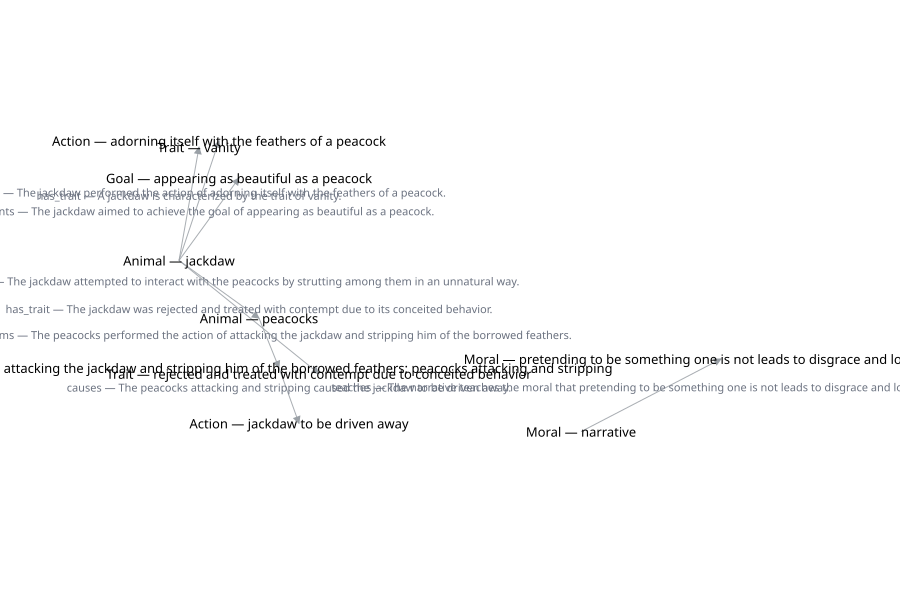

In [5]:
# Deterministic alternative: NetworkX Kamada-Kawai layout.
graphicalizer.display(trace.graph, mode="static")